Import Python modules

In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

Read in energy landscapes

In [2]:
score_fns = ["beta_nov16", "beta_jan25"]
dfs = []
for name in score_fns:
    df = pd.read_csv(f"results/lj_energies_{name}.csv")
    df["score_fn"] = name
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
df = df[df['total'] < 0.01]
df.head()

,pair,d,lj_atr,lj_rep,fa_atr,fa_rep,total,score_fn
11,CH3:CH3,3.500443,-0.062642,0.106879,-0.062642,0.058783,-0.003859,beta_nov16
12,CH3:CH3,3.561982,-0.062642,0.072693,-0.062642,0.039981,-0.022661,beta_nov16
13,CH3:CH3,3.623520,-0.062642,0.047890,-0.062642,0.026340,-0.036302,beta_nov16
14,CH3:CH3,3.685058,-0.062642,0.030190,-0.062642,0.016605,-0.046037,beta_nov16
15,CH3:CH3,3.746597,-0.062642,0.017860,-0.062642,0.009823,-0.052819,beta_nov16


Plot LJ energy landscapes, showing the total energy

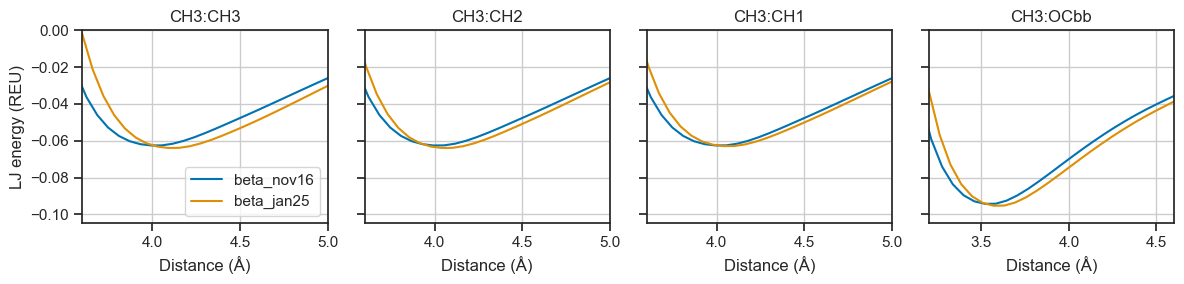

In [3]:
pairs = df["pair"].unique()
fig, axes = plt.subplots(1, len(pairs), figsize=(3 * len(pairs), 3), sharey=True)

for i, (ax, pair) in enumerate(zip(axes, pairs)):
    data = df[df["pair"] == pair]
    sns.lineplot(data=data, x="d", y="total", hue="score_fn", ax=ax)
    ax.set(
        title=pair, xlabel="Distance (Å)", ylabel="LJ energy (REU)",
        ylim=(df['total'].min() * 1.1,0),
    )
    if i < 3:
        ax.set(xlim=[3.6,5.0])
    else:
        ax.set(xlim=[3.2,4.6])
    ax.grid()
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc="lower right")
plt.tight_layout()
plt.show()

For one landscape, plot the energy traces of fa_atr and fa_rep, as well as their sum

<Axes: xlabel='d', ylabel='energy'>

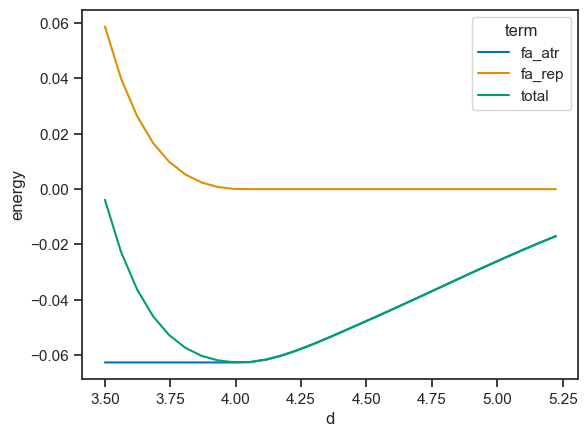

In [4]:
data = df[
    (df["pair"] == 'CH3:CH3') &
    (df["score_fn"] == 'beta_nov16')
][['d', 'fa_atr', 'fa_rep', 'total']]
data = data.melt(
    id_vars='d', value_vars=['fa_atr', 'fa_rep', 'total'],
    var_name='term', value_name='energy'
)
sns.lineplot(data=data, x="d", y="energy", hue="term")